In [1]:
import fiesta
import glob
#from fiesta.surrogates import download_recommended_surrogates
#download_recommended_surrogates()

from survey_sim import DetectionCriteria

from survey_sim import FixedBu2026KilonovaPopulation, SimulationPipeline, load_ztf_survey
from survey_sim import Bu2026KilonovaPopulation
from survey_sim.fiesta_model import FiestaKNModel
from contextlib import redirect_stdout
import io
import math
# from fiesta.surrogates import download_recommended_surrogates; download_recommended_surrogates()

import numpy as np

import matplotlib.pyplot as plt

from survey_sim.fiesta_model import FiestaKNModel

from survey_sim import (
    FixedBu2026KilonovaPopulation,
    DetectionCriteria,
    SimulationPipeline,
    load_ztf_survey,
)

from survey_sim.serialization import save_result, load_result

/opt/anaconda3/envs/surveysim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from concurrent.futures import ThreadPoolExecutor

def load_model_results(path_, max_workers=8):
    files = glob.glob(f"{path_}/*.json")
    print(f"Loading {len(files)} results from {path_}")
    if not files:
        return []
    with ThreadPoolExecutor(max_workers=min(max_workers, len(files))) as pool:
        return list(pool.map(load_result, files))

results_Bu2026Fixed = load_model_results("results/multi_model/Bu2026Fixed")
results_Bu2026Vary = load_model_results("results/multi_model/Bu2026Vary")
results_Metzger = load_model_results("results/multi_model/Metzger")

Loading 10 results from results/multi_model/Bu2026Fixed
Loading 10 results from results/multi_model/Bu2026Vary
Loading 10 results from results/multi_model/Metzger


In [3]:
results = load_model_results("results/marathon")
results_10M = load_model_results("results/")

Loading 100 results from results/marathon
Loading 42 results from results/


In [4]:
results

[SimulationResult(n_simulated=1000000, n_detected=239, efficiency=0.0002, sources=199),
 SimulationResult(n_simulated=1000000, n_detected=232, efficiency=0.0002, sources=173),
 SimulationResult(n_simulated=1000000, n_detected=243, efficiency=0.0002, sources=181),
 SimulationResult(n_simulated=1000000, n_detected=271, efficiency=0.0003, sources=210),
 SimulationResult(n_simulated=1000000, n_detected=272, efficiency=0.0003, sources=225),
 SimulationResult(n_simulated=1000000, n_detected=261, efficiency=0.0003, sources=209),
 SimulationResult(n_simulated=1000000, n_detected=255, efficiency=0.0003, sources=191),
 SimulationResult(n_simulated=1000000, n_detected=278, efficiency=0.0003, sources=208),
 SimulationResult(n_simulated=1000000, n_detected=261, efficiency=0.0003, sources=198),
 SimulationResult(n_simulated=1000000, n_detected=268, efficiency=0.0003, sources=199),
 SimulationResult(n_simulated=1000000, n_detected=266, efficiency=0.0003, sources=211),
 SimulationResult(n_simulated=10

In [5]:
results_Bu2026Vary[0].rate_summaries[0].upper_limit(0.90)

RateUpperLimit(type=Kilonova, N=0, CL=90%, R_upper=1.014e3 Gpc^-3/yr, N_upper=2.303, VT_eff=2.271e-3 Gpc^3 yr)

In [6]:
# display(dir(results[0].rate_summaries[0]))
# display(dir(results[0].rate_summaries[0].upper_limit(0.20)))
display(results[0].rate_summaries[0].upper_limit(0.90).rate_upper)
display(results[1].rate_summaries[0].volumetric_rate)

np.float64(1132.4967325378927)

1000.0

In [7]:
# # Extract upper limits at 20% confidence level from all results
# upper_limits = [[result.rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results]
# upper_limits_10M = [[result.rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results_10M]

/opt/anaconda3/envs/surveysim/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


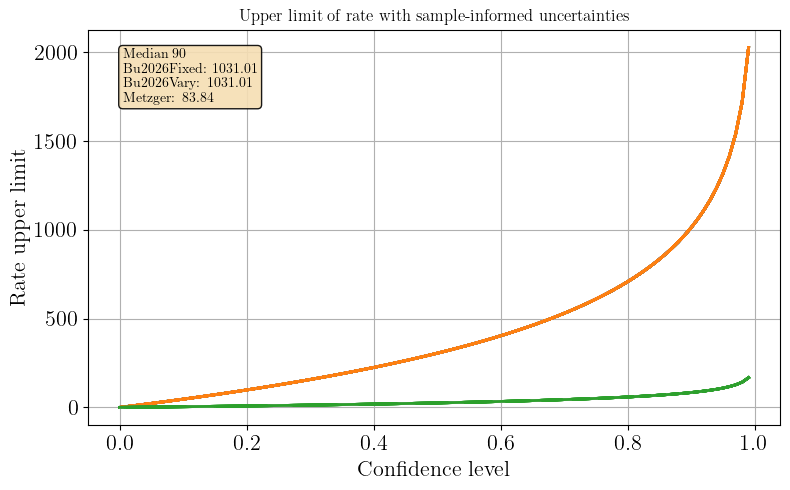

In [8]:
plt.figure(figsize=(8, 5))
# upper_limits = [[results_Bu2026Fixed[0].rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results]

for item in results_Bu2026Fixed:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [[results_Bu2026Fixed[0].rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C0", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C0", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C0", alpha=0.12, label="95% interval")
    
    
for item in results_Bu2026Vary:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [[results_Bu2026Vary[0].rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C1", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C1", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C1", alpha=0.12, label="95% interval")
    
for item in results_Metzger:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [[results_Metzger[0].rate_summaries[0].upper_limit(percentile).rate_upper for percentile in np.linspace(0, 1, 100)] for result in results]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C2", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C2", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C2", alpha=0.12, label="95% interval")
## inlay single text box that lists median 90% upper limit value for each model
median_90_rates = []
for model_ in [results_Bu2026Fixed, results_Bu2026Vary, results_Metzger]:
    median_90_rates.append(np.nanmedian([result.rate_summaries[0].upper_limit(0.90).rate_upper for result in model_]))
textstr = '\n'.join(('Median 90% upper limit:',
                    f'Bu2026Fixed: {median_90_rates[0]:.2f}',
                    f'Bu2026Vary: {median_90_rates[1]:.2f}',
                    f'Metzger: {median_90_rates[2]:.2f}'))
props = {"boxstyle": 'round', "facecolor": 'wheat', "alpha": 0.9}
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
plt.xlabel("Confidence level")
plt.ylabel("Rate upper limit")
plt.title("Upper limit of rate with sample-informed uncertainties")
# plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

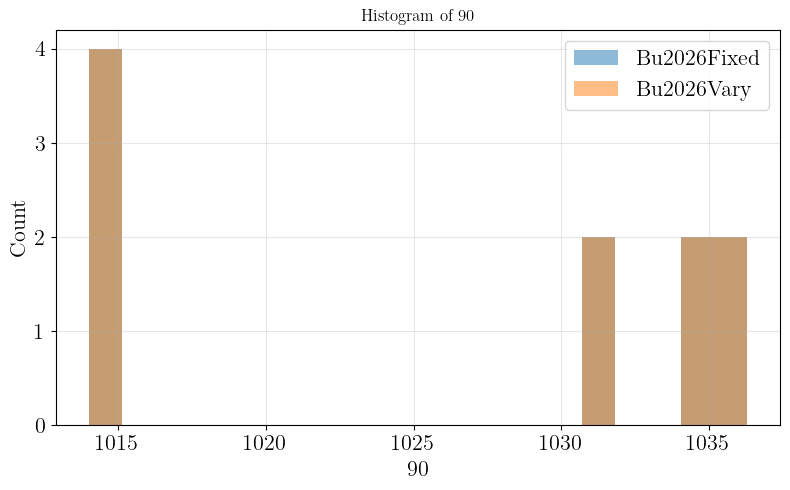

In [16]:
upper_90_fixed = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Bu2026Fixed], dtype=float)
upper_90_vary = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Bu2026Vary], dtype=float)
upper_90_metzger = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Metzger], dtype=float)

upper_90_fixed = upper_90_fixed[np.isfinite(upper_90_fixed)]
upper_90_vary = upper_90_vary[np.isfinite(upper_90_vary)]
upper_90_metzger = upper_90_metzger[np.isfinite(upper_90_metzger)]

# all_vals = np.concatenate([upper_90_fixed, upper_90_vary, upper_90_metzger])
all_vals = np.concatenate([upper_90_fixed, upper_90_vary])
bins = np.histogram_bin_edges(all_vals, bins=20)

plt.figure(figsize=(8, 5))
plt.hist(upper_90_fixed, bins=bins, alpha=0.5, color="C0", label="Bu2026Fixed")
plt.hist(upper_90_vary, bins=bins, alpha=0.5, color="C1", label="Bu2026Vary")
# plt.hist(upper_90_metzger, bins=bins, alpha=0.5, color="C2", label="Metzger")

plt.xlabel("90% upper limit")
plt.ylabel("Count")
plt.title("Histogram of 90% upper limits by model")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

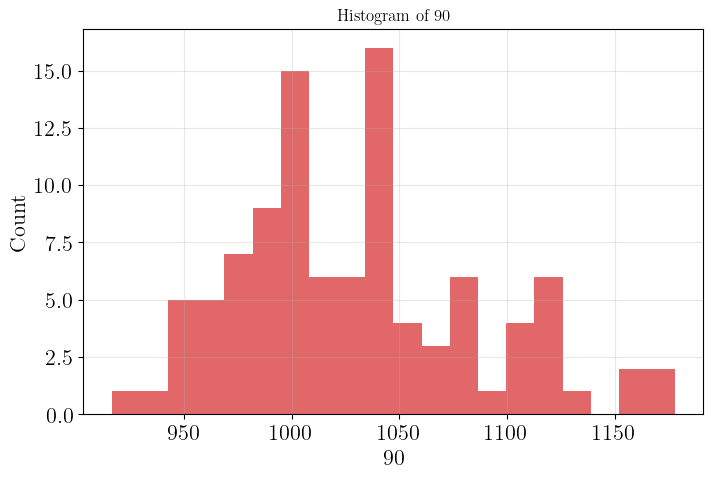

In [14]:
upper_limits_90 = [result.rate_summaries[0].upper_limit(0.90).rate_upper for result in results]
bins = np.histogram_bin_edges(upper_limits_90, bins=20)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(upper_limits_90, bins=bins, alpha=0.7, color="C3", label="90% upper limits")
ax.set_xlabel("90% upper limit")
ax.set_ylabel("Count")
ax.set_title("Histogram of 90% upper limits")
ax.grid(True, alpha=0.3)

/opt/anaconda3/envs/surveysim/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


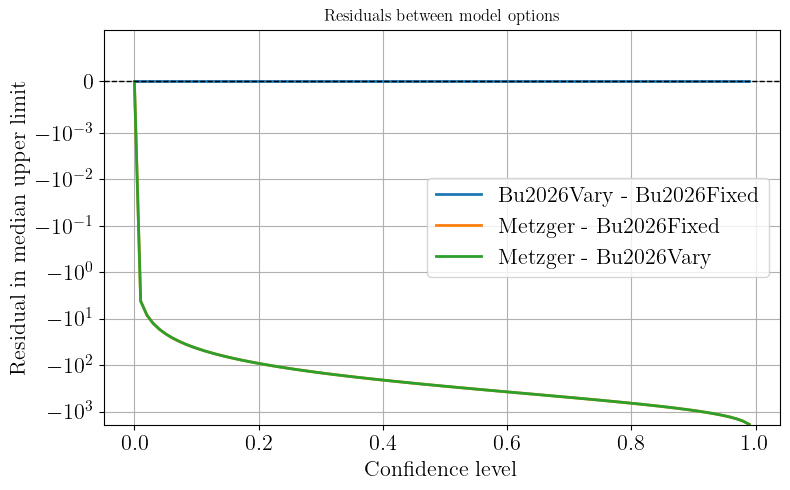

In [10]:
def build_upper_limit_curve(results, n_points=100):
    confidence = np.linspace(0, 1, n_points)
    upper_limits = []
    for result in results:
        upper_limits.append([
            result.rate_summaries[0].upper_limit(p).rate_upper
            for p in confidence
        ])
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan
    return confidence, ul


confidence_fixed, ul_fixed = build_upper_limit_curve(results_Bu2026Fixed)
_, ul_vary = build_upper_limit_curve(results_Bu2026Vary)
_, ul_metzger = build_upper_limit_curve(results_Metzger)

q50_fixed = np.nanpercentile(ul_fixed, 50, axis=0)
q50_vary = np.nanpercentile(ul_vary, 50, axis=0)
q50_metzger = np.nanpercentile(ul_metzger, 50, axis=0)

residuals = [
    ("Bu2026Vary - Bu2026Fixed", q50_vary - q50_fixed),
    ("Metzger - Bu2026Fixed", q50_metzger - q50_fixed),
    ("Metzger - Bu2026Vary", q50_metzger - q50_vary),
]

fig, ax = plt.subplots(figsize=(8, 5))
for label, residual in residuals:
    ax.plot(confidence_fixed, residual, lw=2, label=label)

ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Confidence level")
ax.set_ylabel("Residual in median upper limit")
ax.set_title("Residuals between model options")
ax.grid(True)
ax.legend()
ax.set_yscale("symlog", linthresh=1e-3)
ax.set_ylim(None,1e-3)
plt.tight_layout()
plt.show()

In [11]:
# ul_1m = np.asarray(upper_limits, dtype=float)
# ul_10m = np.asarray(upper_limits_10M, dtype=float)

# ul_1m[~np.isfinite(ul_1m)] = np.nan
# ul_10m[~np.isfinite(ul_10m)] = np.nan

# confidence = np.linspace(0, 1, min(ul_1m.shape[1], ul_10m.shape[1]))

# # Truncate to common confidence grid if needed
# ul_1m = ul_1m[:, : len(confidence)]
# ul_10m = ul_10m[:, : len(confidence)]

# q50_1m = np.nanpercentile(ul_1m, 50, axis=0)
# q16_1m = np.nanpercentile(ul_1m, 16, axis=0)
# q84_1m = np.nanpercentile(ul_1m, 84, axis=0)

# q50_10m = np.nanpercentile(ul_10m, 50, axis=0)
# q16_10m = np.nanpercentile(ul_10m, 16, axis=0)
# q84_10m = np.nanpercentile(ul_10m, 84, axis=0)

# residual = q50_10m - q50_1m
# percent_residual = 100 * residual / q50_1m

# fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ax[0].plot(confidence, q50_1m, label="1M median", color="C0", lw=2)
# ax[0].fill_between(confidence, q16_1m, q84_1m, color="C0", alpha=0.2)
# ax[0].plot(confidence, q50_10m, label="10M median", color="C1", lw=2)
# ax[0].fill_between(confidence, q16_10m, q84_10m, color="C1", alpha=0.2)
# ax[0].set_xlabel("Confidence level")
# ax[0].set_ylabel("Rate upper limit")
# ax[0].set_title("Upper limit comparison")
# ax[0].grid(True)
# ax[0].legend()

# ax[1].axhline(0, color="k", lw=1, ls="--")
# ax[1].plot(confidence, residual, color="C2", lw=2, label="Absolute residual")
# ax[1].set_xlabel("Confidence level")
# ax[1].set_ylabel("10M - 1M")
# ax[1].set_title("Residual of median upper limit")
# ax[1].grid(True)
# ax[1].legend()

# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.axhline(0, color="k", lw=1, ls="--")
# plt.plot(confidence, percent_residual, color="C3", lw=2)
# plt.xlabel("Confidence level")
# plt.ylabel("Residual [%]")
# plt.title("Percent residual: (10M - 1M) / 1M")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [12]:
## distribution of values at 95 percent confidence interval
upper_limits_95 = [result.rate_summaries[0].upper_limit(0.95).rate_upper for result in results_10M]

